In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# El parámetro read_only=True permite abrirla aunque otro proceso la esté usando
con = duckdb.connect('../data/BaseDeDatos_Working.db', read_only=True)

# Inpeccion para el estandarizar los datos

## Lo que hare es que quitare en la los textos acentos extraños ademas poner en formato de Mayuscula y inpeccionar si hay valores con espacios invisibles 

In [3]:
text_columns = con.execute("""
    SELECT table_name, column_name 
    FROM information_schema.columns 
    WHERE data_type = 'VARCHAR' 
      AND table_schema = 'main'
""").fetchall()

print(f"Auditando {len(text_columns)} columnas de texto...\n")

for table, col in text_columns:
    stats = con.execute(f"""
        SELECT 
            COUNT(*) as total,
            SUM(CASE WHEN "{col}" != TRIM("{col}") THEN 1 ELSE 0 END) as con_espacios,
            SUM(CASE WHEN regexp_matches("{col}", '[áéíóúÁÉÍÓÚüÜñÑ]') THEN 1 ELSE 0 END) as con_acentos_especiales,
            SUM(CASE WHEN "{col}" != UPPER("{col}") AND "{col}" != LOWER("{col}") THEN 1 ELSE 0 END) as mezcla_case
        FROM {table}
    """).fetchone()
    
    if stats[1] > 0 or stats[2] > 0 or stats[3] > 0:
        print(f"Tabla: {table} | Columna: {col}")
        print(f"   - Espacios extra (inicio/fin): {stats[1]}")
        print(f"   - Con acentos/caracteres: {stats[2]}")
        print(f"   - Mezcla Mayúsculas/Minúsculas: {stats[3]}")
        print("-" * 30)

Auditando 22 columnas de texto...

Tabla: causa | Columna: causa
   - Espacios extra (inicio/fin): 1
   - Con acentos/caracteres: 9
   - Mezcla Mayúsculas/Minúsculas: 54
------------------------------
Tabla: causa | Columna: causa_especifica
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 10
   - Mezcla Mayúsculas/Minúsculas: 54
------------------------------
Tabla: danos | Columna: tamanio
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 12703
   - Mezcla Mayúsculas/Minúsculas: 12703
------------------------------
Tabla: diccionario | Columna: fuente
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 0
   - Mezcla Mayúsculas/Minúsculas: 3
------------------------------
Tabla: diccionario | Columna: nombre_completo
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 0
   - Mezcla Mayúsculas/Minúsculas: 146
------------------------------
Tabla: diccionario | Columna: unidad_de_medida
   - Espacios extra (inicio/fin): 0
   - Con

Duplicados semanticos

In [4]:
mapeo_auditoria_completo = {}
for tabla, columna in text_columns:
    if tabla not in mapeo_auditoria_completo:
        mapeo_auditoria_completo[tabla] = []
    mapeo_auditoria_completo[tabla].append(columna)

print("Mapeo de auditoría generado automáticamente:")
for tabla, cols in mapeo_auditoria_completo.items():
    print(f"   - {tabla}: {cols}")

Mapeo de auditoría generado automáticamente:
   - causa: ['causa', 'causa_especifica']
   - climatologia: ['id_variable', 'id_clave_inc']
   - danos: ['id_clave_inc', 'tamanio']
   - demografia: ['id_cvegeo', 'sexo']
   - diccionario: ['id_variable', 'fuente', 'nombre_completo', 'unidad_de_medida']
   - estado: ['region', 'estado']
   - incendios: ['id_clave_inc', 'id_cvegeo', 'tipo_de_incendio']
   - municipios: ['id_cvegeo', 'nombre_municipio']
   - operaciones: ['id_clave_inc']
   - vegetacion: ['regimen_del_fuego', 'tipo_de_vegetacion']


In [5]:
for tabla, columnas in mapeo_auditoria_completo.items():
    for col in columnas:
        query = f"""
            SELECT 
                LOWER(TRIM(regexp_replace("{col}", '[áéíóúÁÉÍÓÚüÜñÑ]', 'aeiouAEIOU', 'g'))) as version_estandar,
                ARRAY_AGG(DISTINCT "{col}") as variaciones_encontradas,
                COUNT(DISTINCT "{col}") as total_variaciones
            FROM {tabla}
            GROUP BY 1
            HAVING total_variaciones > 1
        """
        
        try:
            df_res = con.execute(query).df()
            if not df_res.empty:
                print(f" PROBLEMA ENCONTRADO -> Tabla: {tabla} | Columna: {col}")
                print(df_res)
                print("-" * 60)
        except Exception as e:
            continue

print("\nAuditoría finalizada.")

 PROBLEMA ENCONTRADO -> Tabla: causa | Columna: causa
  version_estandar                     variaciones_encontradas  \
0      intencional                  [Intencional, intencional]   
1        cazadores                      [Cazadores, cazadores]   
2     otras causas  [Otras causas, otras causas, otras Causas]   
3          fogatas                [fogatas, Fogatas, Fogatas ]   

   total_variaciones  
0                  2  
1                  2  
2                  3  
3                  3  
------------------------------------------------------------
 PROBLEMA ENCONTRADO -> Tabla: causa | Columna: causa_especifica
                                    version_estandar  \
0                                              otras   
1  mineraeiouaeioua (extracciaeiouaeioun de mater...   
2                                         vandalismo   

                             variaciones_encontradas  total_variaciones  
0                                     [otras, Otras]                  2  
1

In [6]:
def estandarizar_textos_global(con):
    print("   - [Transform] Estandarizando textos (Mayúsculas, acentos y espacios)...")
    
    # Este mapeo lo construimos gracias al auditor que corriste en Jupyter
    mapeo_limpieza = {
        'municipios': ['nombre_municipio'],
        'causa': ['causa', 'causa_especifica'],
        'vegetacion': ['tipo_de_vegetacion'],
        'incendios': ['tipo_de_incendio'],
        'danos': ['tamanio']
    }

    for tabla, columnas in mapeo_limpieza.items():
        for col in columnas:
            # Versión Ganadora: Regex + Lower + Trim
            query = f"""
                UPDATE {tabla} SET "{col}" = 
                LOWER(TRIM(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace("{col}", '[áÁ]', 'a', 'g'),
                                           '[éÉ]', 'e', 'g'),
                                           '[íÍ]', 'i', 'g'),
                                           '[óÓ]', 'o', 'g'),
                                           '[úÚüÜ]', 'u', 'g'),
                                           '[ñÑ]', 'n', 'g')
                ))
            """
            con.execute(query)
    print("   - [Transform] ¡Base de datos estandarizada para el modelo!")

# Toma de Decisiones

## Huerfanos

In [7]:
con = duckdb.connect('../data/BaseDeDatos_Working.db', read_only=True)

# 1. Consultamos el catálogo de llaves foráneas
# DuckDB guarda las relaciones en la tabla 'duckdb_constraints'
query_relaciones = """
    SELECT 
        table_name AS tabla_hija,
        constraint_column_names[1] AS columna_fk,
        referenced_table AS tabla_padre
    FROM duckdb_constraints
    WHERE constraint_type = 'FOREIGN KEY'
"""

relaciones_detectadas = con.execute(query_relaciones).fetchall()

# 2. Convertimos el resultado al formato que necesitamos para la auditoría
relaciones = []
print("🔍 RELACIONES DETECTADAS EN EL ESQUEMA:")
print(f"{'TABLA HIJA':<15} | {'COLUMNA FK':<15} | {'TABLA PADRE':<15}")
print("-" * 50)

for hija, fk, padre in relaciones_detectadas:
    # Como tus PK suelen llamarse igual que las FK, las mapeamos así:
    # Nota: Si una PK se llama diferente, DuckDB también nos lo puede decir
    relaciones.append((hija, fk, padre, fk)) 
    print(f"{hija:<15} | {fk:<15} | {padre:<15}")

# Ahora 'relaciones' ya no es una lista manual, ¡es dinámica!

🔍 RELACIONES DETECTADAS EN EL ESQUEMA:
TABLA HIJA      | COLUMNA FK      | TABLA PADRE    
--------------------------------------------------
climatologia    | id_variable     | diccionario    
climatologia    | id_clave_inc    | incendios      
danos           | id_clave_inc    | incendios      
demografia      | id_cvegeo       | municipios     
incendios       | id_cvegeo       | municipios     
incendios       | id_causa        | causa          
incendios       | id_vegetacion   | vegetacion     
municipios      | id_clave_ent    | estado         
operaciones     | id_clave_inc    | incendios      


In [8]:
print(" INICIANDO AUDITORÍA DINÁMICA DE INTEGRIDAD...\n")
hay_problemas = False

for hija, fk, padre, pk in relaciones:
    query = f"""
        SELECT COUNT(*) 
        FROM main.{hija} h
        LEFT JOIN main.{padre} p ON h.{fk} = p.{pk}
        WHERE p.{pk} IS NULL AND h.{fk} IS NOT NULL
    """
    
    total_huerfanos = con.execute(query).fetchone()[0]
    
    if total_huerfanos > 0:
        hay_problemas = True
        print(f"TABLA: {hija:<12} | FK: {fk:<15} | HUÉRFANOS: {total_huerfanos}")
        
        # Obtenemos una muestra de los IDs que no existen en el padre
        muestras = con.execute(f"""
            SELECT DISTINCT h.{fk} 
            FROM main.{hija} h 
            LEFT JOIN main.{padre} p ON h.{fk} = p.{pk} 
            WHERE p.{pk} IS NULL LIMIT 3
        """).fetchall()
        print(f" IDs que no están en '{padre}': {[m[0] for m in muestras]}")
        print("-" * 60)
    else:
        print(f"TABLA: {hija:<12} | Relación con '{padre}' perfecta.")

if not hay_problemas:
    print("\n¡Felicidades! Tu base de datos es una roca. No hay registros huérfanos.")
else:
    print("\nSe encontraron huérfanos. Necesitamos decidir si borrar o corregir.")

 INICIANDO AUDITORÍA DINÁMICA DE INTEGRIDAD...

TABLA: climatologia | Relación con 'diccionario' perfecta.
TABLA: climatologia | Relación con 'incendios' perfecta.
TABLA: danos        | Relación con 'incendios' perfecta.
TABLA: demografia   | Relación con 'municipios' perfecta.
TABLA: incendios    | Relación con 'municipios' perfecta.
TABLA: incendios    | Relación con 'causa' perfecta.
TABLA: incendios    | Relación con 'vegetacion' perfecta.
TABLA: municipios   | Relación con 'estado' perfecta.
TABLA: operaciones  | Relación con 'incendios' perfecta.

¡Felicidades! Tu base de datos es una roca. No hay registros huérfanos.


# Lógica Temporal (Por el momento no se limpian)

In [9]:
import pandas as pd

# 1. ¿Hay incendios que terminan antes de empezar?
# Comparamos fecha_inicio (tabla incendios) vs fecha_termino (tabla operaciones)
print("REVISANDO LÓGICA DE FECHAS...")
query_fechas = """
    SELECT i.id_clave_inc, i.fecha_inicio, o.fecha_termino
    FROM main.incendios i
    JOIN main.operaciones o ON i.id_clave_inc = o.id_clave_inc
    WHERE o.fecha_termino < i.fecha_inicio
"""
df_fechas_locas = con.execute(query_fechas).df()

# 2. ¿Hay brigadas que llegan antes de detectar el incendio?
# Comparamos hora_deteccion vs hora_llegada (en el mismo día)
print("🔍 REVISANDO LÓGICA DE HORARIOS...")
query_horas = """
    SELECT id_clave_inc, hora_deteccion, hora_llegada
    FROM main.operaciones
    WHERE hora_llegada < hora_deteccion
"""
df_horas_locas = con.execute(query_horas).df()

# Reporte de resultados
if df_fechas_locas.empty and df_horas_locas.empty:
    print("\n¡Cronología perfecta! Todo ocurre en el orden correcto.")
else:
    if not df_fechas_locas.empty:
        print(f"Se encontraron {len(df_fechas_locas)} registros con fechas invertidas.")
    if not df_horas_locas.empty:
        print(f"Se encontraron {len(df_horas_locas)} registros con horarios imposibles.")

REVISANDO LÓGICA DE FECHAS...
🔍 REVISANDO LÓGICA DE HORARIOS...
Se encontraron 136 registros con horarios imposibles.


In [10]:
# Ver los registros donde el incendio "termina antes de empezar"
if not df_fechas_locas.empty:
    print("📋 DETALLE DE FECHAS INVERTIDAS:")
    # Traemos también el municipio para ver si es un problema de una región específica
    detalle_fechas = con.execute("""
        SELECT i.id_clave_inc, m.nombre_municipio, i.fecha_inicio, o.fecha_termino
        FROM main.incendios i
        JOIN main.operaciones o ON i.id_clave_inc = o.id_clave_inc
        JOIN main.municipios m ON i.id_cvegeo = m.id_cvegeo
        WHERE o.fecha_termino < i.fecha_inicio
    """).df()
    print(display(detalle_fechas)) # display() se ve mejor que print() en Jupyter

In [11]:
if not df_horas_locas.empty:
    print("\nDETALLE DE HORARIOS IMPOSIBLES:")
    detalle_horas = con.execute("""
        SELECT id_clave_inc, hora_deteccion, hora_llegada, duracion_hhmm
        FROM main.operaciones
        WHERE hora_llegada < hora_deteccion
    """).df()
    display(detalle_horas)


DETALLE DE HORARIOS IMPOSIBLES:


,id_clave_inc,hora_deteccion,hora_llegada,duracion_hhmm
0,15-15-0196,00:06:00,00:04:00,0 days 01:17:00
1,15-15-0245,00:25:00,00:20:00,0 days 03:20:00
2,17-15-0317,00:10:00,00:05:00,0 days 01:55:00
3,17-15-0717,00:15:00,00:10:00,0 days 02:35:00
4,18-15-0394,00:10:00,00:05:00,0 days 00:55:00
...,...,...,...,...
131,21-15-1488,00:10:00,00:05:00,0 days 00:55:00
132,22-15-0886,02:24:00,00:10:00,0 days 06:10:00
133,24-15-0177,00:12:00,00:00:00,NaT
134,24-15-0510,00:11:00,00:00:00,NaT


# Valores Numericos en climatologia

Generando radiografía de 14 millones de datos (Muestra de 100k)...


/tmp/ipykernel_6266/4026106703.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='id_variable', y='resultado_numerico', data=df_sample, palette="Set2")


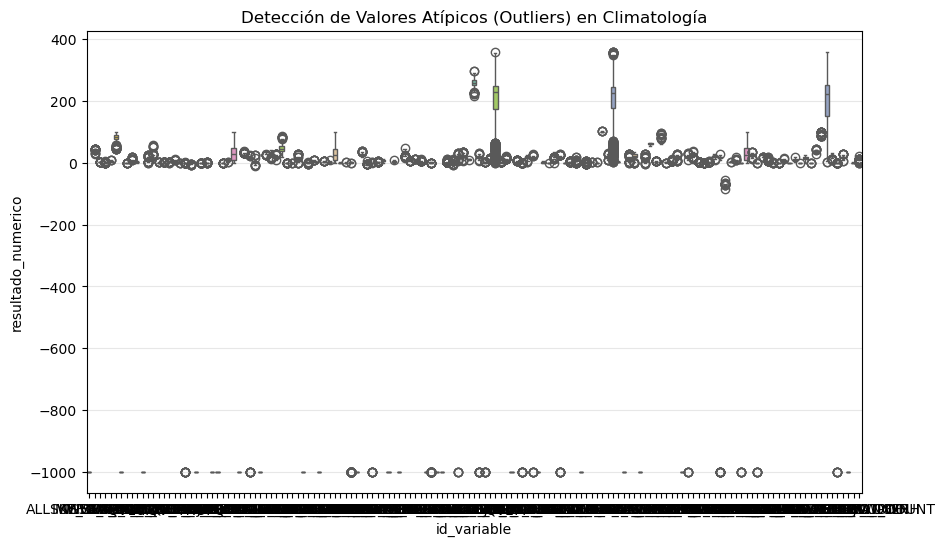

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generando radiografía de 14 millones de datos (Muestra de 100k)...")

# Tomamos una muestra para no saturar la memoria RAM
df_sample = con.execute("""
    SELECT resultado_numerico, id_variable 
    FROM main.climatologia 
    USING SAMPLE 100000;
""").df()

# Graficamos
plt.figure(figsize=(10, 6))
sns.boxplot(x='id_variable', y='resultado_numerico', data=df_sample, palette="Set2")
plt.title("Detección de Valores Atípicos (Outliers) en Climatología")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
# Buscamos variables con valores imposibles
resumen_loco = con.execute("""
    SELECT id_variable, 
           MIN(resultado_numerico) as minimo, 
           MAX(resultado_numerico) as maximo,
           COUNT(*) FILTER (WHERE resultado_numerico <= -999) as total_nulos_codificados
    FROM main.climatologia
    GROUP BY id_variable
    HAVING minimo <= -999 OR maximo > 100
""").df()

print("🚩 Variables que necesitan limpieza urgente:")
display(resumen_loco)

🚩 Variables que necesitan limpieza urgente:


,id_variable,minimo,maximo,total_nulos_codificados
0,TSOIL1,-999.000000,33.580002,1050
1,TSOIL4,-999.000000,30.580000,1050
2,WD50M,0.000000,360.000000,0
3,GWM_HEIGHT,-999.000000,-999.000000,96950
4,SNODP,-999.000000,10.650000,1050
5,SZA,-999.000000,-999.000000,96950
6,CLOUD_TT,-999.000000,-999.000000,96960
7,IMERG_PRECLIQUID_PROB,-999.000000,-999.000000,96940
8,SFMC,-999.000000,-999.000000,96940
9,SWLAND,-999.000000,-999.000000,96940


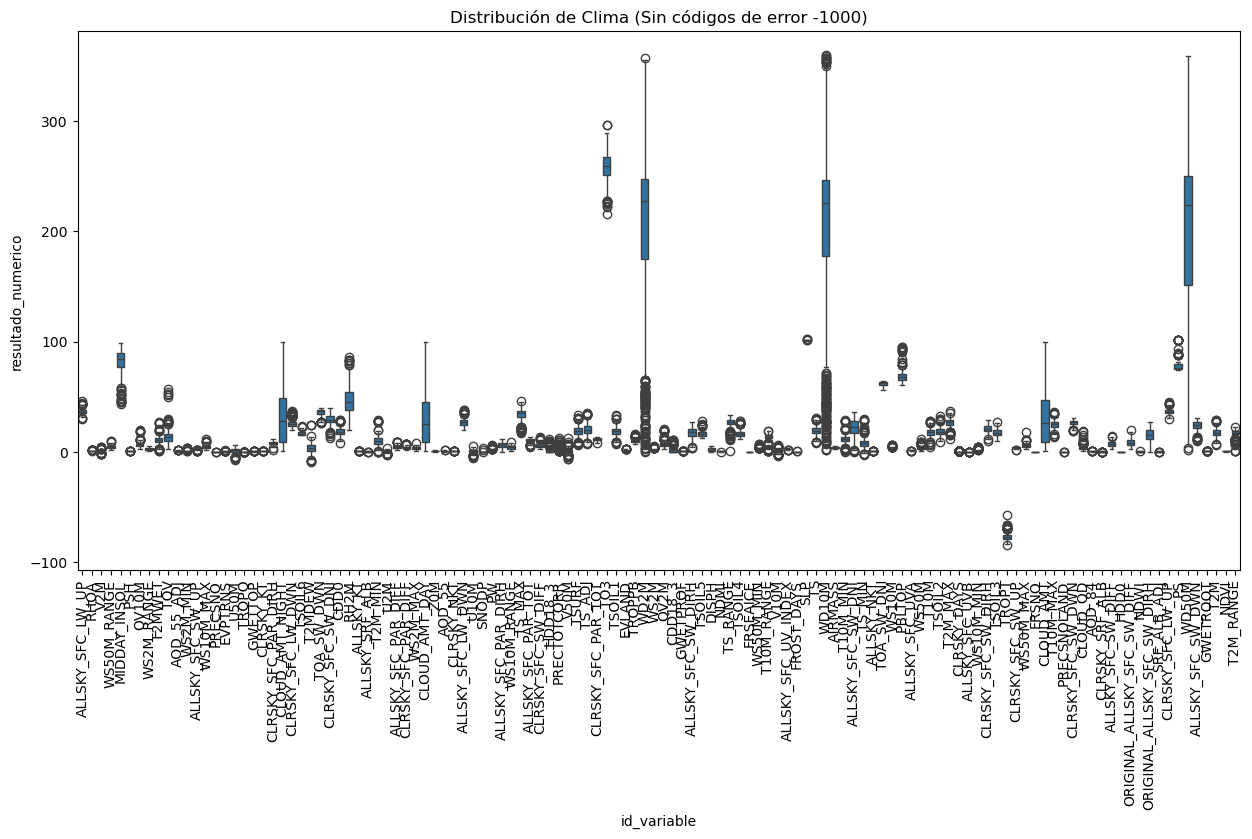

In [14]:
# Filtramos los códigos de error para ver la distribución real
df_real = df_sample[df_sample['resultado_numerico'] > -500]

plt.figure(figsize=(15, 7))
sns.boxplot(x='id_variable', y='resultado_numerico', data=df_real)
plt.xticks(rotation=90) # Giramos los nombres para que no se encimen
plt.title("Distribución de Clima (Sin códigos de error -1000)")
plt.show()

In [ ]:
Codigos para el def 

def estandarizar_textos_global(con):
    print("   - [Transform] Estandarizando textos (Mayúsculas, acentos y espacios)...")
    
    # Este mapeo lo construimos gracias al auditor que corriste en Jupyter
    mapeo_limpieza = {
        'municipios': ['nombre_municipio'],
        'causa': ['causa', 'causa_especifica'],
        'vegetacion': ['tipo_de_vegetacion'],
        'incendios': ['tipo_de_incendio'],
        'danos': ['tamanio']
    }

    for tabla, columnas in mapeo_limpieza.items():
        for col in columnas:
            # Versión Ganadora: Regex + Lower + Trim
            query = f"""
                UPDATE {tabla} SET "{col}" = 
                LOWER(TRIM(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace("{col}", '[áÁ]', 'a', 'g'),
                                           '[éÉ]', 'e', 'g'),
                                           '[íÍ]', 'i', 'g'),
                                           '[óÓ]', 'o', 'g'),
                                           '[úÚüÜ]', 'u', 'g'),
                                           '[ñÑ]', 'n', 'g')
                ))
            """
            con.execute(query)
    print("   - [Transform] ¡Base de datos estandarizada para el modelo!")


# Identificamos las variables que son 100% basura
variables_basura = resumen_loco[resumen_loco['minimo'] == -999][resumen_loco['maximo'] == -999]['id_variable'].tolist()

print(f"Eliminando {len(variables_basura)} variables que no contienen información útil...")

# Borramos esos registros de la tabla
if variables_basura:
    con.execute(f"DELETE FROM main.climatologia WHERE id_variable IN ({str(variables_basura)[1:-1]})")
    # También hay que quitarlas del diccionario para que tu Cubo OLAP esté limpio
    con.execute(f"DELETE FROM main.diccionario WHERE id_variable IN ({str(variables_basura)[1:-1]})")

print("✅ Variables muertas eliminadas.")


# Borramos cualquier registro que tenga el código de error -999
con.execute("DELETE FROM main.climatologia WHERE resultado_numerico <= -999")

filas_restantes = con.execute("SELECT COUNT(*) FROM main.climatologia").fetchone()[0]
print(f"✅ Limpieza completada. Filas útiles restantes: {filas_restantes:,}")

# Ponemos en NULL las coordenadas que están fuera de los límites lógicos del Edomex
con.execute("""
    UPDATE main.incendios 
    SET latitud = NULL, longitud = NULL
    WHERE latitud NOT BETWEEN 18.3 AND 20.3
       OR longitud NOT BETWEEN -100.6 AND -98.5
       OR (latitud = 0 AND longitud = 0)
""")
print("✅ Coordenadas imposibles reseteadas a NULL.")

In [ ]:
# Coordenadas aproximadas del Estado de México
# Latitud: 18.3 a 20.3 | Longitud: -100.6 a -98.5
print("📍 Verificando que los incendios estén dentro del Estado de México...")
query_espacial = """
    SELECT id_clave_inc, latitud, longitud, m.nombre_municipio
    FROM main.incendios i
    JOIN main.municipios m ON i.id_cvegeo = m.id_cvegeo
    WHERE latitud NOT BETWEEN 18.3 AND 20.3
       OR longitud NOT BETWEEN -100.6 AND -98.5
"""
df_fuera_rango = con.execute(query_espacial).df()

if df_fuera_rango.empty:
    print("✅ Todos los incendios están dentro de los límites esperados.")
else:
    print(f"⚠️ Se encontraron {len(df_fuera_rango)} incendios con coordenadas sospechosas.")
    display(df_fuera_rango.head())


📍 Verificando que los incendios estén dentro del Estado de México...
⚠️ Se encontraron 116 incendios con coordenadas sospechosas.


,id_clave_inc,latitud,longitud,nombre_municipio
0,15-15-0188,0.000000,0.000000,Jocotitlán
1,15-15-0190,0.000000,0.000000,Zinacantepec
2,16-15-0410,0.000000,0.000000,Calimaya
3,16-15-0633,18.990473,-92.367889,Ocuilan
4,16-15-0826,0.000000,0.000000,Jocotitlán


In [16]:
import pandas as pd

print("🔍 AUDITANDO TABLA DE DAÑOS (Hectáreas y consistencia)...")

# 1. Buscamos hectáreas negativas o totales exagerados (> 10,000 ha como alerta inicial)
query_danos_locos = """
    SELECT 
        d.id_clave_inc, 
        m.nombre_municipio,
        hojarasca, arbustivo, herbaceo, arbolado_adulto, renuevo,
        (hojarasca + arbustivo + herbaceo + arbolado_adulto + renuevo) AS total_calculado
    FROM main.danos d
    JOIN main.incendios i ON d.id_clave_inc = i.id_clave_inc
    JOIN main.municipios m ON i.id_cvegeo = m.id_cvegeo
    WHERE hojarasca < 0 OR arbustivo < 0 OR herbaceo < 0 OR arbolado_adulto < 0 OR renuevo < 0
       OR (hojarasca + arbustivo + herbaceo + arbolado_adulto + renuevo) > 10000
"""

df_danos_alertas = con.execute(query_danos_locos).df()

if df_danos_alertas.empty:
    print("✅ No se detectaron hectáreas negativas ni incendios mayores a 10,000 ha.")
else:
    print(f"⚠️ Se encontraron {len(df_danos_alertas)} registros con valores sospechosos.")
    display(df_danos_alertas)

🔍 AUDITANDO TABLA DE DAÑOS (Hectáreas y consistencia)...
✅ No se detectaron hectáreas negativas ni incendios mayores a 10,000 ha.
